# TDOA Estimate Error Analysis

### Jimmy Jamison

This notebooks performs a Monte Carlo simulation to compare cross-correlation, GCC-PHAT, and MUSIC TDOA estimation algorithms.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

import sys
import os
sys.path.append(os.path.abspath('..'))
import utils

In [2]:
from scipy.interpolate import interp1d
from scipy.optimize import minimize_scalar

def find_interpolated_peak(x, y):
    """
    From Google AI

    Finds the (x, y) coordinates of the peak of a curve using
    quadratic interpolation.
    """
    # 1. Create the quadratic interpolation function
    # Note: interp1d is considered legacy; for new code, consider make_interp_spline
    f = interp1d(x, y, kind='quadratic', fill_value="extrapolate")

    # 2. Define the objective function to MINIMIZE (negate for maximization)
    def objective(x_val):
        return -f(x_val)

    # 3. Find the maximum within the bounds of the original x data
    res = minimize_scalar(objective, bounds=(min(x), max(x)), method='bounded')

    peak_x = res.x
    peak_y = f(peak_x)

    return peak_x, peak_y

## Peak Finding

num_samples: 500
True TDOA: -50
CC Interpolated Estimate: -49.9706773744225
MUSIC Estimate: -50.05
GCC-PHAT Estimate: -50
GCC-PHAT Interpolated Estimate: -49.87144823996303


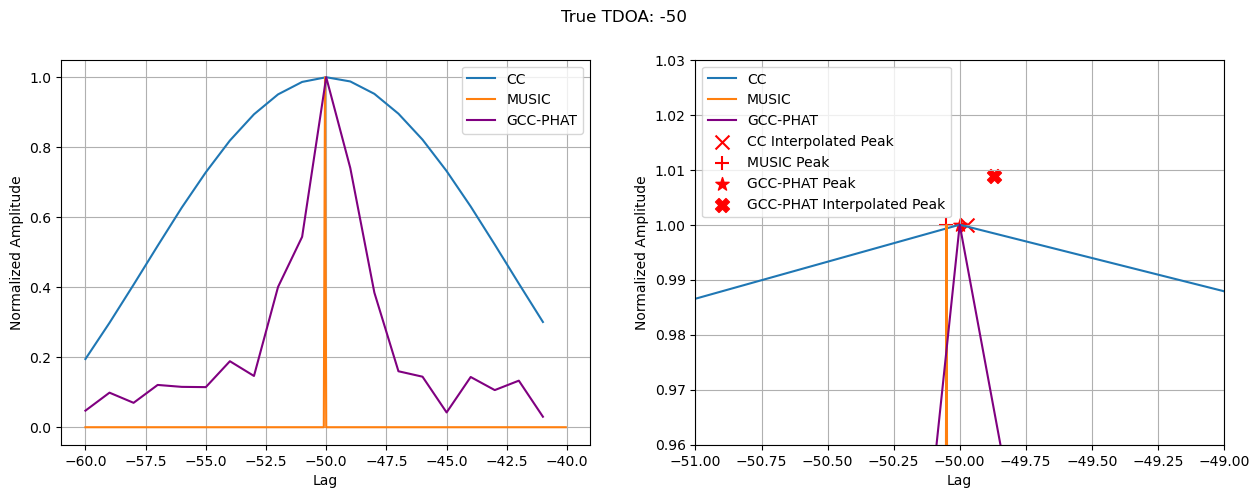

In [3]:
num_symbols = 40
samples_per_symbol = 10
signal = utils.random_qpsk_data(num_symbols, samples_per_symbol, utils.Pulse.RAISED_COSINE)

num_samples = num_symbols * samples_per_symbol + 100
print(f"num_samples: {num_samples}")
snr_db = 20.

tdoa = -50
toas0 = [20]
toas1 = [toas0[0]-tdoa]

snrs0 = [snr_db] * len(toas0)
y0 = utils.sensor(signal, num_samples, toas0, snrs0)

snrs1 = [snr_db] * len(toas1)
y1 = utils.sensor(signal, num_samples, toas1, snrs1)

true_tdoas = []
for toa0 in toas0:
    for toa1 in toas1:
        true_tdoas.append(toa0-toa1)
true_tdoas = list(set(true_tdoas))

l1, tdoa1 = utils.tdoa_cc(y0, y1, lag_min=-60, lag_max=-40)
est_tdoa1, est_mag1 = find_interpolated_peak(l1, tdoa1)

l2, tdoa2 = utils.tdoa_super(y0, y1, lag_min=-60, lag_max=-40, k=len(true_tdoas), D=20)
est_tdoa2 = l2[np.argmax(tdoa2)]
est_mag2 = np.max(tdoa2)

l3, tdoa3 = utils.tdoa_gccphat(y0, y1, lag_min=-60, lag_max=-40)
est_tdoa3 = l3[np.argmax(tdoa3)]
est_mag3 = np.max(tdoa3)
est_tdoa4, est_mag4 = find_interpolated_peak(l3, tdoa3)

print(f"True TDOA: {tdoa}")
print(f"CC Interpolated Estimate: {est_tdoa1}")
print(f"MUSIC Estimate: {est_tdoa2}")
print(f"GCC-PHAT Estimate: {est_tdoa3}")
print(f"GCC-PHAT Interpolated Estimate: {est_tdoa4}")

plt.figure(figsize=(15,5))
plt.suptitle(f"True TDOA: {tdoa}")

plt.subplot(1,2,1)
plt.plot(l1, tdoa1, label='CC')
plt.plot(l2, tdoa2, label='MUSIC')
plt.plot(l3, tdoa3, label='GCC-PHAT', color='purple')
plt.legend()
plt.ylabel("Normalized Amplitude")
plt.xlabel("Lag")
plt.grid()

plt.subplot(1,2,2)
plt.plot(l1, tdoa1, label='CC')
plt.plot(l2, tdoa2, label='MUSIC')
plt.plot(l3, tdoa3, label='GCC-PHAT', color='purple')
plt.scatter(est_tdoa1, est_mag1, s=100, marker='x', color='red', label='CC Interpolated Peak')
plt.scatter(est_tdoa2, est_mag2, s=100, marker='+', color='red', label='MUSIC Peak')
plt.scatter(est_tdoa3, est_mag3, s=100, marker='*', color='red', label='GCC-PHAT Peak')
plt.scatter(est_tdoa4, est_mag4, s=100, marker='X', color='red', label='GCC-PHAT Interpolated Peak')
plt.xlim([tdoa-1, tdoa+1])
plt.ylim([0.96, 1.03])
plt.legend()
plt.ylabel("Normalized Amplitude")
plt.xlabel("Lag")
plt.grid()



num_samples: 500
True TDOA: -59.5
CC Interpolated Estimate: -59.51221068774331
MUSIC Estimate: -59.05
GCC-PHAT Estimate: -59
GCC-PHAT Interpolated Estimate: -59.41298124480057


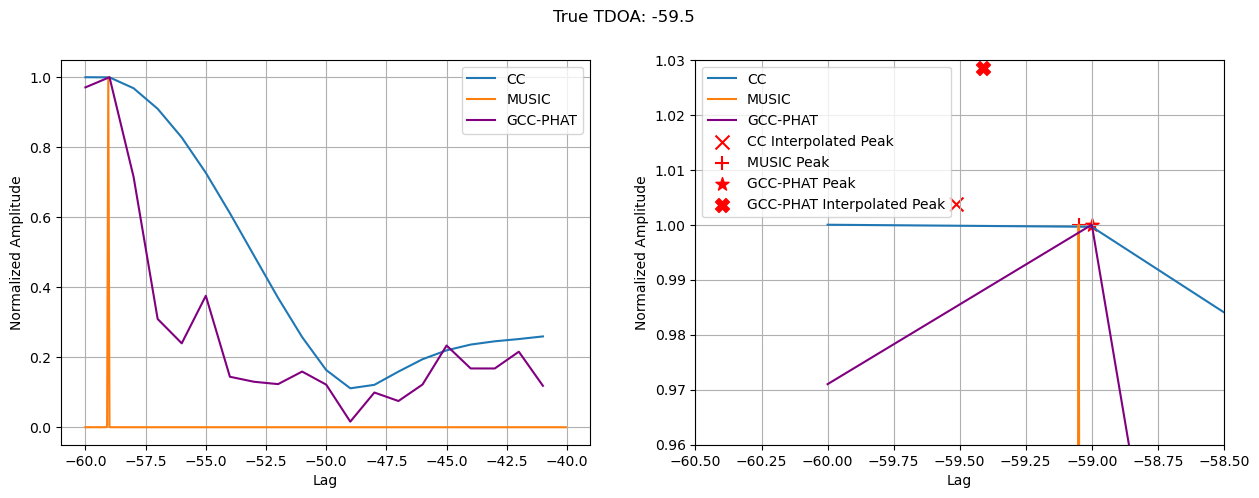

In [7]:
num_symbols = 40
samples_per_symbol = 10
signal = utils.random_qpsk_data(num_symbols, samples_per_symbol, utils.Pulse.RAISED_COSINE)

num_samples = num_symbols * samples_per_symbol + 100
print(f"num_samples: {num_samples}")
snr_db = 20.

tdoa = -59.5
toas0 = [20]
toas1 = [toas0[0]-tdoa]

snrs0 = [snr_db] * len(toas0)
y0 = utils.sensor(signal, num_samples, toas0, snrs0)

snrs1 = [snr_db] * len(toas1)
y1 = utils.sensor(signal, num_samples, toas1, snrs1)

true_tdoas = []
for toa0 in toas0:
    for toa1 in toas1:
        true_tdoas.append(toa0-toa1)
true_tdoas = list(set(true_tdoas))

l1, tdoa1 = utils.tdoa_cc(y0, y1, lag_min=-60, lag_max=-40)
est_tdoa1, est_mag1 = find_interpolated_peak(l1, tdoa1)

l2, tdoa2 = utils.tdoa_super(y0, y1, lag_min=-60, lag_max=-40, k=len(true_tdoas), D=20)
est_tdoa2 = l2[np.argmax(tdoa2)]
est_mag2 = np.max(tdoa2)

l3, tdoa3 = utils.tdoa_gccphat(y0, y1, lag_min=-60, lag_max=-40)
est_tdoa3 = l3[np.argmax(tdoa3)]
est_mag3 = np.max(tdoa3)
est_tdoa4, est_mag4 = find_interpolated_peak(l3, tdoa3)

print(f"True TDOA: {tdoa}")
print(f"CC Interpolated Estimate: {est_tdoa1}")
print(f"MUSIC Estimate: {est_tdoa2}")
print(f"GCC-PHAT Estimate: {est_tdoa3}")
print(f"GCC-PHAT Interpolated Estimate: {est_tdoa4}")

plt.figure(figsize=(15,5))
plt.suptitle(f"True TDOA: {tdoa}")

plt.subplot(1,2,1)
plt.plot(l1, tdoa1, label='CC')
plt.plot(l2, tdoa2, label='MUSIC')
plt.plot(l3, tdoa3, label='GCC-PHAT', color='purple')
plt.legend()
plt.ylabel("Normalized Amplitude")
plt.xlabel("Lag")
plt.grid()

plt.subplot(1,2,2)
plt.plot(l1, tdoa1, label='CC')
plt.plot(l2, tdoa2, label='MUSIC')
plt.plot(l3, tdoa3, label='GCC-PHAT', color='purple')
plt.scatter(est_tdoa1, est_mag1, s=100, marker='x', color='red', label='CC Interpolated Peak')
plt.scatter(est_tdoa2, est_mag2, s=100, marker='+', color='red', label='MUSIC Peak')
plt.scatter(est_tdoa3, est_mag3, s=100, marker='*', color='red', label='GCC-PHAT Peak')
plt.scatter(est_tdoa4, est_mag4, s=100, marker='X', color='red', label='GCC-PHAT Interpolated Peak')
plt.xlim([tdoa-1, tdoa+1])
plt.ylim([0.96, 1.03])
plt.legend()
plt.ylabel("Normalized Amplitude")
plt.xlabel("Lag")
plt.grid()



## No Multipath (1 TDOA Component)

SNR: -10 dB
SNR: -5 dB
SNR: 0 dB
SNR: 5 dB
SNR: 10 dB
SNR: 15 dB
SNR: 20 dB
SNR: 25 dB
SNR: 30 dB


Text(0, 0.5, 'RMSE (s)')

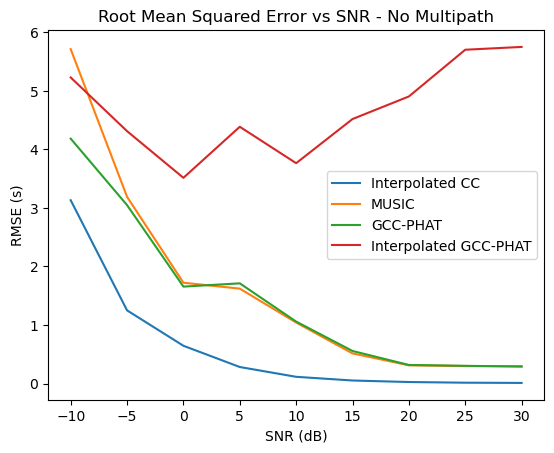

In [ ]:
num_symbols = 40
samples_per_symbol = 10
num_samples = num_symbols * samples_per_symbol + 100

snrs = [-10, -5, 0, 5, 10, 15, 20, 25, 30]
num_realizations = 100

errors1 = np.zeros((len(snrs), num_realizations), dtype=float)
errors2 = np.zeros((len(snrs), num_realizations), dtype=float)
errors3 = np.zeros((len(snrs), num_realizations), dtype=float)
errors4 = np.zeros((len(snrs), num_realizations), dtype=float)

# This sim takes ~30mins to run
# Each realization takes ~2.5 seconds
for six, snr in enumerate(snrs):
    print(f"SNR: {snr} dB")

    for rix in range(num_realizations):

        signal = utils.random_qpsk_data(num_symbols, samples_per_symbol, utils.Pulse.RAISED_COSINE)

        # make random and handle non-interger TDOAs
        tdoa = np.random.uniform(-59,-41)
        toas0 = [20]
        toas1 = [toas0[0]-tdoa]

        snrs0 = [snr]*len(toas0)
        y0 = utils.sensor(signal, num_samples, toas0, snrs0)
        snrs1 = [snr]*len(toas1)
        y1 = utils.sensor(signal, num_samples, toas1, snrs1)

        l1, tdoa1 = utils.tdoa_cc(y0, y1, lag_min=-60, lag_max=-40)
        est_tdoa1, _ = find_interpolated_peak(l1, tdoa1)
        errors1[six,rix] = (est_tdoa1-tdoa)

        l2, tdoa2 = utils.tdoa_super(y0, y1, lag_min=-60, lag_max=-40, k=len(true_tdoas), D=20)
        est_tdoa2 = l2[np.argmax(tdoa2)]
        errors2[six,rix] = (est_tdoa2-tdoa)

        l3, tdoa3 = utils.tdoa_gccphat(y0, y1, lag_min=-60, lag_max=-40)
        est_tdoa3 = l3[np.argmax(tdoa3)]
        errors3[six,rix] = (est_tdoa3-tdoa)

        est_tdoa4, _ = find_interpolated_peak(l3, tdoa3)
        errors4[six,rix] = (est_tdoa4-tdoa)

mse1 = np.sqrt(np.mean(errors1**2, axis=1))
mse2 = np.sqrt(np.mean(errors2**2, axis=1))
mse3 = np.sqrt(np.mean(errors3**2, axis=1))

mse4 = np.sqrt(np.mean(errors4**2, axis=1))

plt.figure()
plt.title("Root Mean Squared Error vs SNR - No Multipath")

plt.plot(snrs, mse1, label="Interpolated CC")
plt.plot(snrs, mse2, label="MUSIC")
plt.plot(snrs, mse3, label="GCC-PHAT")
plt.plot(snrs, mse4, label="Interpolated GCC-PHAT")

plt.legend()
plt.xlabel("SNR (dB)")
plt.ylabel("RMSE (s)")

Text(0, 0.5, 'MSE (dB)')

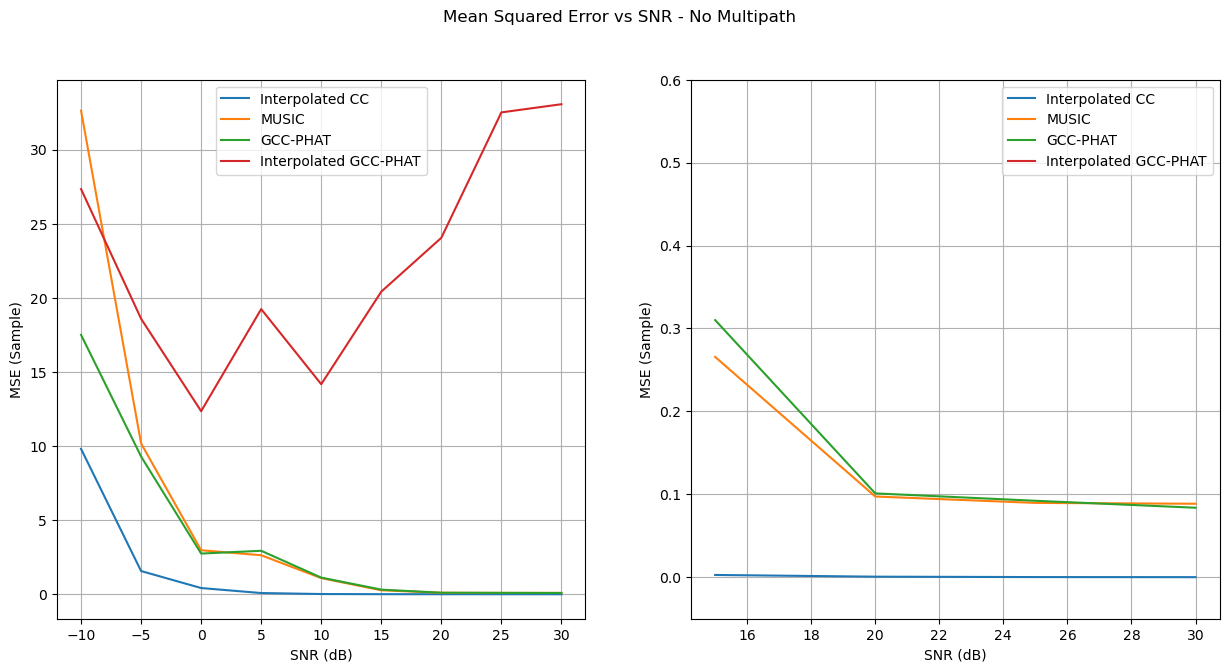

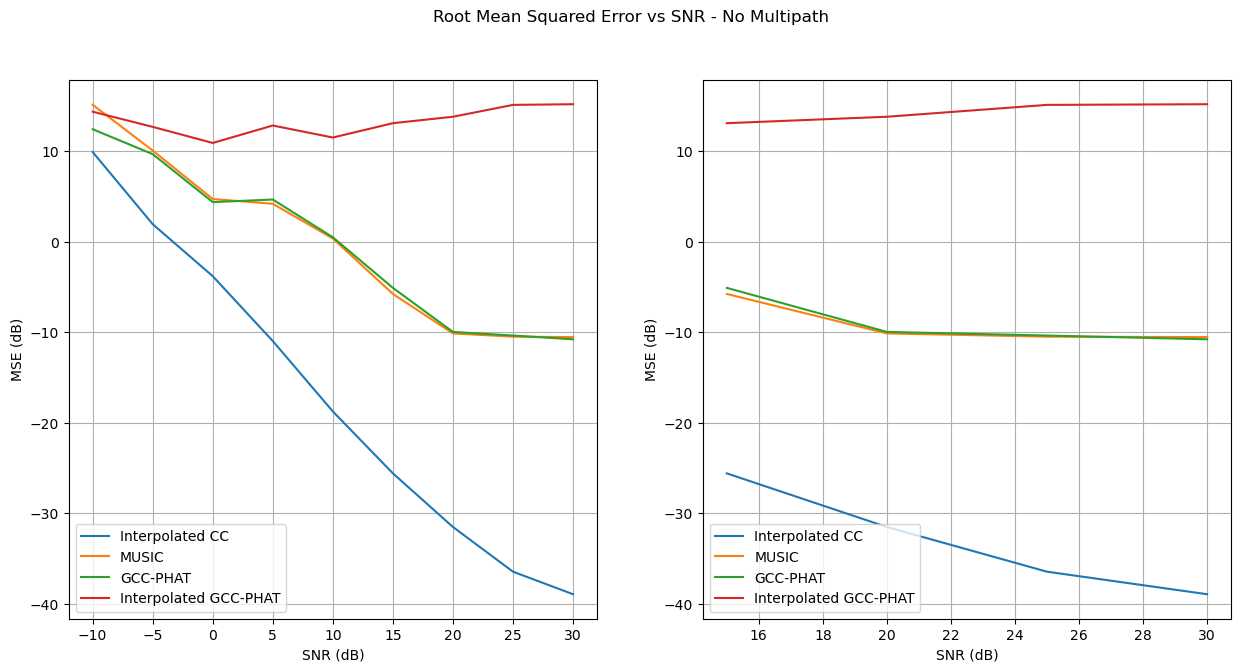

In [22]:
mse1 = np.mean(errors1**2, axis=1)
mse2 = np.mean(errors2**2, axis=1)
mse3 = np.mean(errors3**2, axis=1)
mse4 = np.mean(errors4**2, axis=1)

plt.figure(figsize=(15,7))

plt.suptitle("Mean Squared Error vs SNR - No Multipath")

plt.subplot(1,2,1)

plt.plot(snrs, mse1, label="Interpolated CC")
plt.plot(snrs, mse2, label="MUSIC")
plt.plot(snrs, mse3, label="GCC-PHAT")
plt.plot(snrs, mse4, label="Interpolated GCC-PHAT")

plt.legend()
plt.grid()
plt.xlabel("SNR (dB)")
plt.ylabel("MSE (Sample)")

plt.subplot(1,2,2)

plt.plot(snrs[-4:], mse1[-4:], label="Interpolated CC")
plt.plot(snrs[-4:], mse2[-4:], label="MUSIC")
plt.plot(snrs[-4:], mse3[-4:], label="GCC-PHAT")
plt.plot(snrs[-4:], mse4[-4:], label="Interpolated GCC-PHAT")
plt.ylim([-0.05, 0.6])

plt.legend()
plt.grid()
plt.xlabel("SNR (dB)")
plt.ylabel("MSE (Sample)")

plt.figure(figsize=(15,7))

plt.suptitle("Root Mean Squared Error vs SNR - No Multipath")

plt.subplot(1,2,1)

plt.plot(snrs, 10*np.log10(mse1), label="Interpolated CC")
plt.plot(snrs, 10*np.log10(mse2), label="MUSIC")
plt.plot(snrs, 10*np.log10(mse3), label="GCC-PHAT")
plt.plot(snrs, 10*np.log10(mse4), label="Interpolated GCC-PHAT")

plt.legend()
plt.grid()
plt.xlabel("SNR (dB)")
plt.ylabel("MSE (dB)")

plt.subplot(1,2,2)

plt.plot(snrs[-4:], 10*np.log10(mse1[-4:]), label="Interpolated CC")
plt.plot(snrs[-4:], 10*np.log10(mse2[-4:]), label="MUSIC")
plt.plot(snrs[-4:], 10*np.log10(mse3[-4:]), label="GCC-PHAT")
plt.plot(snrs[-4:], 10*np.log10(mse4[-4:]), label="Interpolated GCC-PHAT")

plt.legend()
plt.grid()
plt.xlabel("SNR (dB)")
plt.ylabel("MSE (dB)")


Text(0, 0.5, 'Variance (dB)')

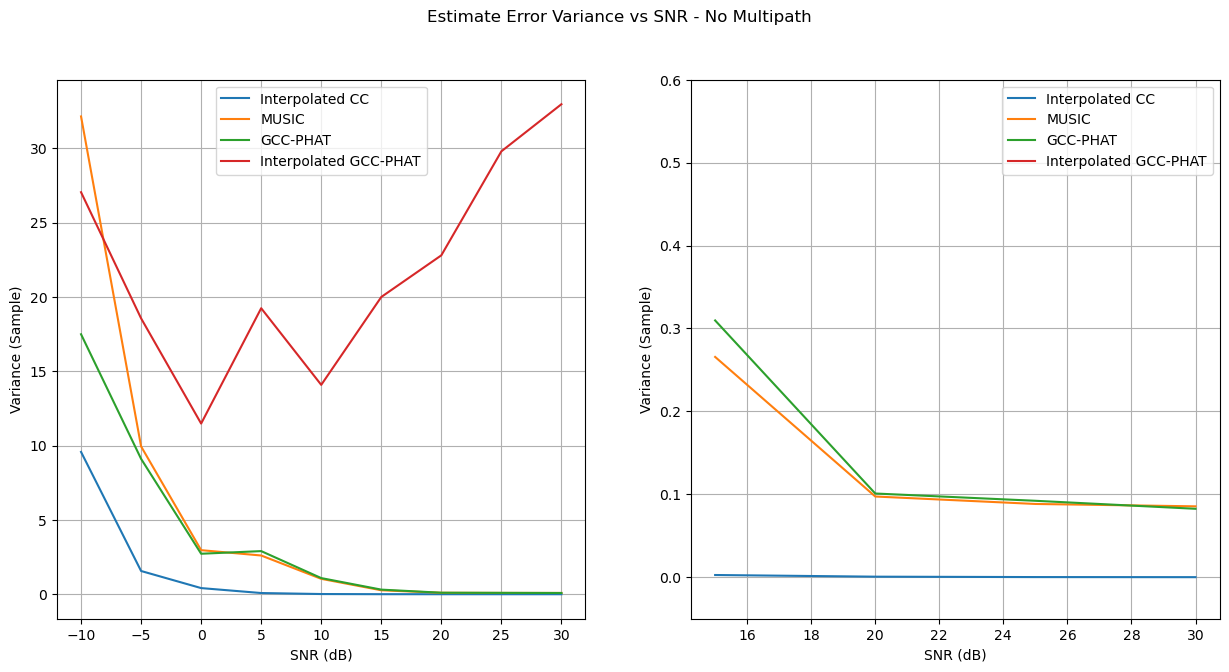

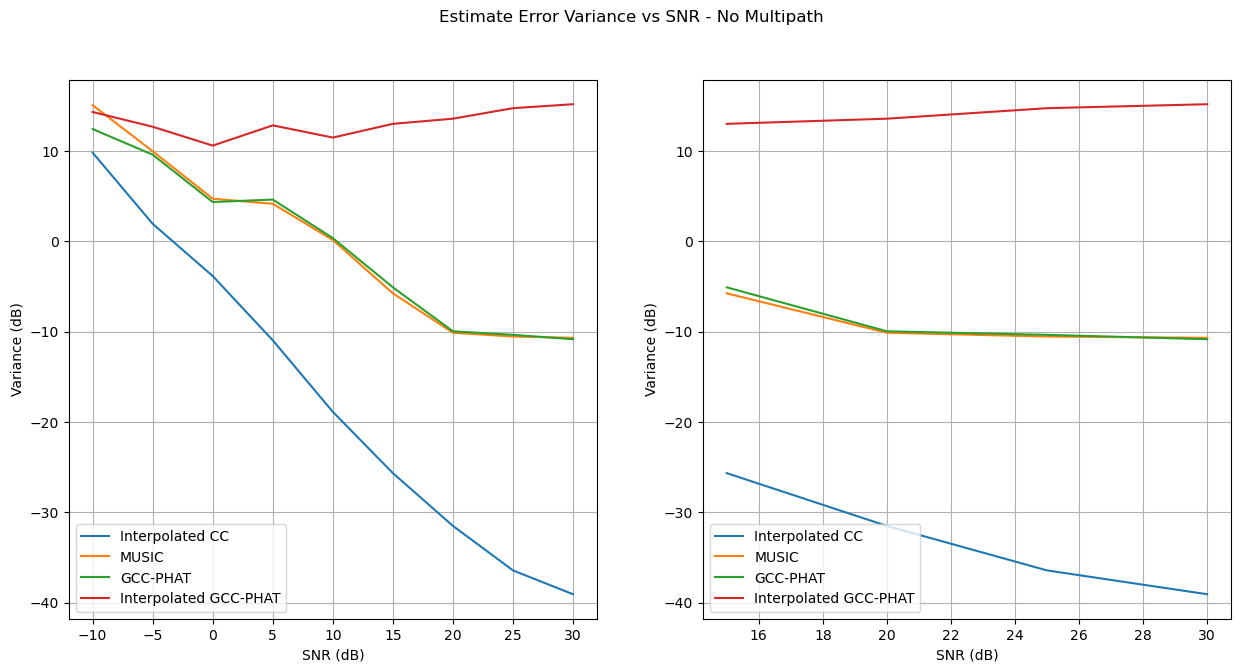

In [26]:
# Compute variance

var1 = np.var(errors1, axis=1)
var2 = np.var(errors2, axis=1)
var3 = np.var(errors3, axis=1)
var4 = np.var(errors4, axis=1)

plt.figure(figsize=(15,7))

plt.suptitle("Estimate Error Variance vs SNR - No Multipath")

plt.subplot(1,2,1)

plt.plot(snrs, var1, label="Interpolated CC")
plt.plot(snrs, var2, label="MUSIC")
plt.plot(snrs, var3, label="GCC-PHAT")
plt.plot(snrs, var4, label="Interpolated GCC-PHAT")

plt.legend()
plt.grid()
plt.xlabel("SNR (dB)")
plt.ylabel("Variance (Sample)")

plt.subplot(1,2,2)

plt.plot(snrs[-4:], var1[-4:], label="Interpolated CC")
plt.plot(snrs[-4:], var2[-4:], label="MUSIC")
plt.plot(snrs[-4:], var3[-4:], label="GCC-PHAT")
plt.plot(snrs[-4:], var4[-4:], label="Interpolated GCC-PHAT")
plt.ylim([-0.05, 0.6])

plt.legend()
plt.grid()
plt.xlabel("SNR (dB)")
plt.ylabel("Variance (Sample)")

plt.figure(figsize=(15,7))

plt.suptitle("Estimate Error Variance vs SNR - No Multipath")

plt.subplot(1,2,1)

plt.plot(snrs, 10*np.log10(var1), label="Interpolated CC")
plt.plot(snrs, 10*np.log10(var2), label="MUSIC")
plt.plot(snrs, 10*np.log10(var3), label="GCC-PHAT")
plt.plot(snrs, 10*np.log10(var4), label="Interpolated GCC-PHAT")

plt.legend()
plt.grid()
plt.xlabel("SNR (dB)")
plt.ylabel("Variance (dB)")

plt.subplot(1,2,2)

plt.plot(snrs[-4:], 10*np.log10(var1[-4:]), label="Interpolated CC")
plt.plot(snrs[-4:], 10*np.log10(var2[-4:]), label="MUSIC")
plt.plot(snrs[-4:], 10*np.log10(var3[-4:]), label="GCC-PHAT")
plt.plot(snrs[-4:], 10*np.log10(var4[-4:]), label="Interpolated GCC-PHAT")

plt.legend()
plt.grid()
plt.xlabel("SNR (dB)")
plt.ylabel("Variance (dB)")
